In [1]:
# Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import seaborn as sns

from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')
%matplotlib inline

from sklearn import datasets

from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import DBSCAN

from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import linkage
from yellowbrick.cluster import SilhouetteVisualizer

import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

    X   Y
0  10   4
1   8  99
2  34  44
3   9  50
4  46  77
5  68  30
    X   Y
0  20  15
1  20  80
2  50  50


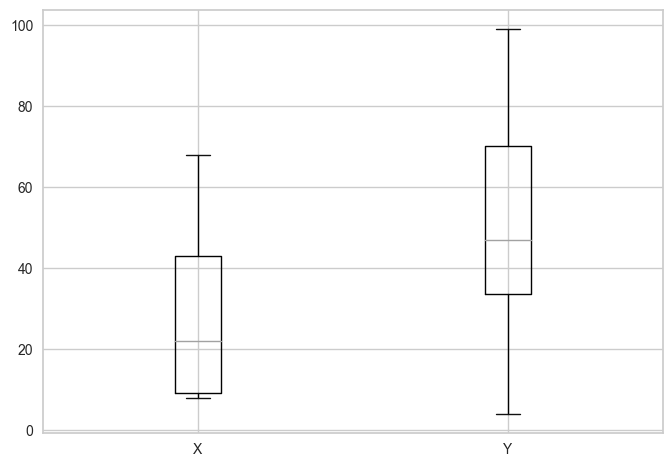

In [2]:
# Datos de ejemplo de clases
df = pd.DataFrame() # datos
x = [10, 8, 34, 9, 46, 68]
y = [4, 99, 44, 50, 77, 30]

df['X'] = x
df['Y'] = y

print(df)
df.boxplot()
df.describe()

# nuevos datos
new = pd.DataFrame() 
new['X'] = [20, 20, 50]
new['Y'] = [15, 80, 50]

print(new)

# Dataframe para los resultados
df2=df
# Dataframe para resultados de las predicciones
new2=new
# Definir colores para los grupos
colors = {0: "red", 1: "blue", 2: "green", 3: "yellow"}

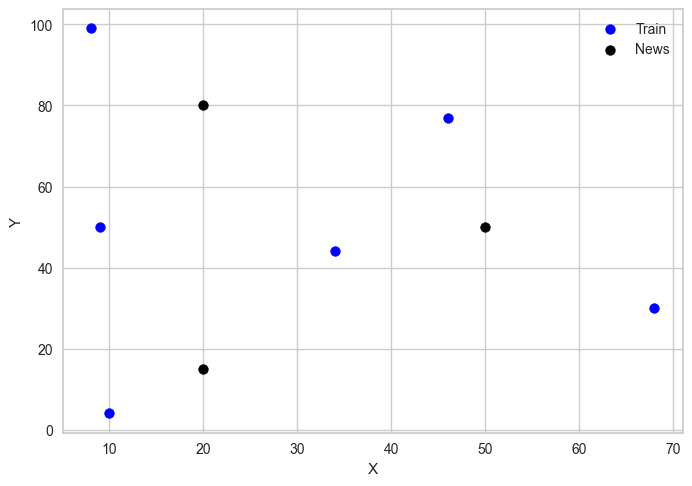

In [3]:
# Graficos de dispersión de datos originales y nuevos
plt.scatter(df['X'], df['Y'], s = 50, c = 'blue', label="Train")
plt.scatter(new['X'], new['Y'], s = 50, c = 'black', label="News")

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [4]:
## Metodología Mezcla de Gaussianas (2 componentes)
clust2_GMM = GaussianMixture(n_components=2, random_state=10).fit(df[['X','Y']])
print(clust2_GMM.means_)
print(clust2_GMM.covariances_)
y2_gmm=clust2_GMM.predict(df[['X','Y']])
print(y2_gmm)

# agregar resultado a dataframe
df2['GMM2'] = y2_gmm
print(df2)

# colores para entrenamiento
color_gmm2 = df2.GMM2.map(colors)

## Predicir nuevos datos
new_gmm2=clust2_GMM.predict(new[['X','Y']].to_numpy().tolist())

# agregar predicción
new2['GMM2'] = new_gmm2
print(new2)

# Definir colores a los puntos predichos
color_new_gmm2 = new2.GMM2.map(colors)

[[26.9999416  88.00003381]
 [30.25002411 32.00007083]]
[[[ 361.000001   -209.        ]
  [-209.          121.000001  ]]

 [[ 575.18699218   38.50101728]
  [  38.50101728  314.00271833]]]
[1 0 1 1 0 1]
    X   Y  GMM2
0  10   4     1
1   8  99     0
2  34  44     1
3   9  50     1
4  46  77     0
5  68  30     1
    X   Y  GMM2
0  20  15     1
1  20  80     1
2  50  50     1


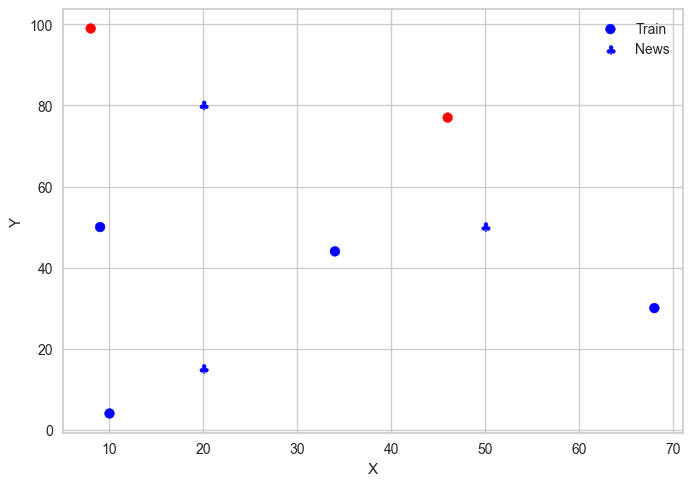

In [5]:
# Grafica de los grupos formados (2 componentes)
plt.scatter(df['X'], df['Y'], s = 50, c = color_gmm2, label="Train")
plt.scatter(new['X'], new['Y'], s = 50, c = color_new_gmm2, marker = r'$\clubsuit$', label="News")

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [6]:
## Metodología Mezcla de Gaussianas (3 componentes)

clust3_GMM = GaussianMixture(n_components=3, covariance_type='spherical').fit(df[['X','Y']])
print(clust3_GMM.means_)
print(clust3_GMM.covariances_)
y3_gmm=clust3_GMM.predict(df[['X','Y']])
print(y3_gmm)

# agregar resultado a dataframe
df2['GMM3'] = y3_gmm
print(df2)

# colores para entrenamiento
color_gmm3 = df2.GMM3.map(colors)

## Predicir nuevos datos
new_gmm3=clust3_GMM.predict(new[['X','Y']].to_numpy().tolist())

# agregar predicción
new2['GMM3'] = new_gmm3
print(new2)

# Definir colores a los puntos predichos
color_new_gmm3 = new2.GMM3.map(colors)


[[68.         30.        ]
 [17.85513899 32.50633671]
 [26.34701275 85.91180838]]
[1.00000688e-06 2.89240880e+02 2.76287677e+02]
[1 2 1 1 2 0]
    X   Y  GMM2  GMM3
0  10   4     1     1
1   8  99     0     2
2  34  44     1     1
3   9  50     1     1
4  46  77     0     2
5  68  30     1     0
    X   Y  GMM2  GMM3
0  20  15     1     1
1  20  80     1     2
2  50  50     1     1


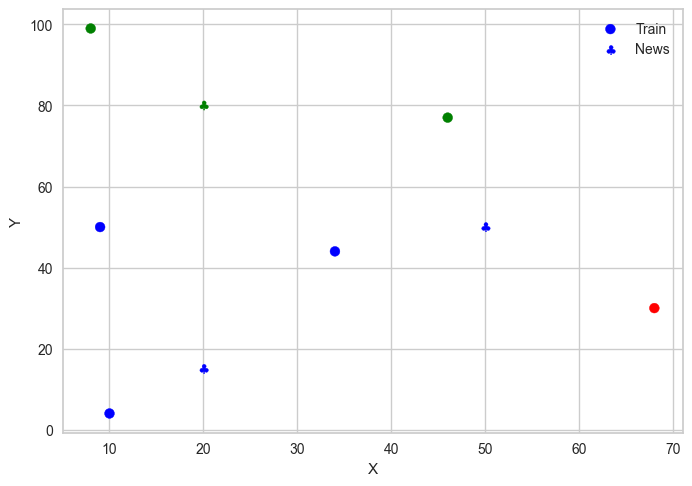

In [7]:
# Grafica de los grupos formados (3 componentes)
plt.scatter(df['X'], df['Y'], s = 50, c = color_gmm3, label="Train")
plt.scatter(new['X'], new['Y'], s = 50, c = color_new_gmm3, marker = r'$\clubsuit$', label="News")

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [8]:
## Variar el tipo de covarianza en el GMM (2 componentes)
clust4_GMM = GaussianMixture(n_components=2, covariance_type='spherical').fit(df[['X','Y']])
print(clust4_GMM.means_)
print(clust4_GMM.covariances_)
y4_gmm=clust4_GMM.predict(df[['X','Y']])
print(y4_gmm)

# agregar resultado a dataframe
df2['GMM4'] = y4_gmm
print(df2)

# colores para entrenamiento
color_gmm4 = df2.GMM4.map(colors)

## Predicir nuevos datos
new_gmm4=clust4_GMM.predict(new[['X','Y']].to_numpy().tolist())
print(new_gmm4)

# agregar predicción
new2['GMM4'] = new_gmm4
print(new2)

# Definir colores a los puntos predichos
color_new_gmm4 = new2.GMM4.map(colors)

[[30.29529027 63.16218588]
 [26.76752826 24.10468454]]
[596.88221586 478.59953029]
[1 0 0 0 0 0]
    X   Y  GMM2  GMM3  GMM4
0  10   4     1     1     1
1   8  99     0     2     0
2  34  44     1     1     0
3   9  50     1     1     0
4  46  77     0     2     0
5  68  30     1     0     0
[1 0 0]
    X   Y  GMM2  GMM3  GMM4
0  20  15     1     1     1
1  20  80     1     2     0
2  50  50     1     1     0


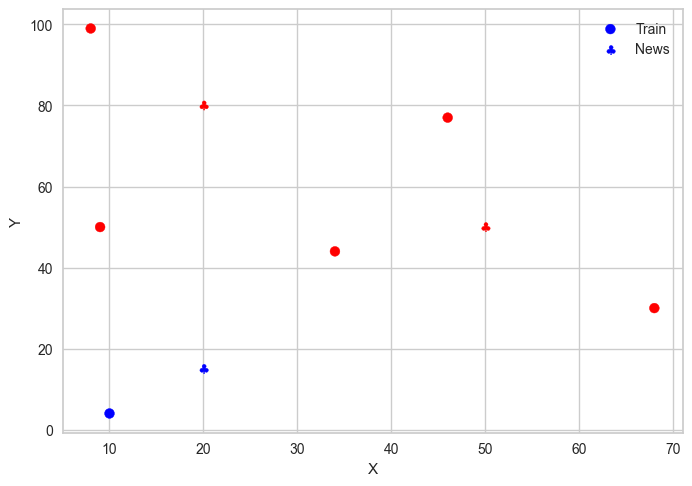

In [9]:
# Grafica de los grupos formados (2 componentes, covarianza diagonal)
plt.scatter(df['X'], df['Y'], s = 50, c = color_gmm4, label="Train")
plt.scatter(new['X'], new['Y'], s = 50, c = color_new_gmm4, marker = r'$\clubsuit$', label="News")

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [10]:
## Ejercicio: Ver como quedan los cluster con los otros tipos de varianza.

,Sepal_length,Sepal_width,Petal_length,Petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


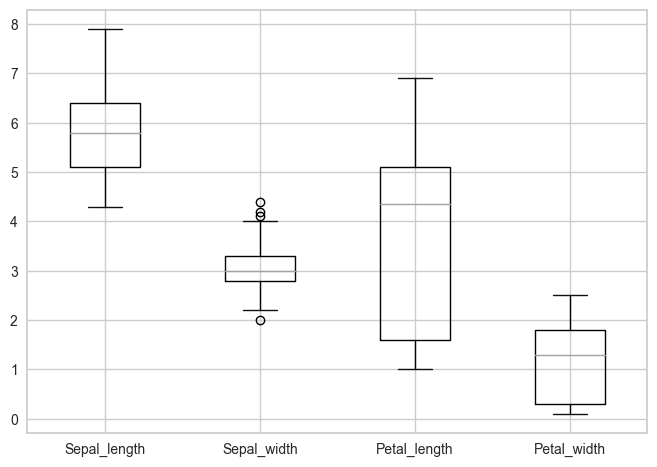

In [11]:
## Ejemplo: Aplicar todas las metodologias vistas hasta el momento a la base iris

# Base de datos iris
iris = datasets.load_iris()

X = pd.DataFrame(iris.data)
y = iris.target

X.columns = ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']

X.boxplot()
round(X.describe(),2)

,Sepal_length,Sepal_width,Petal_length,Petal_width
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71


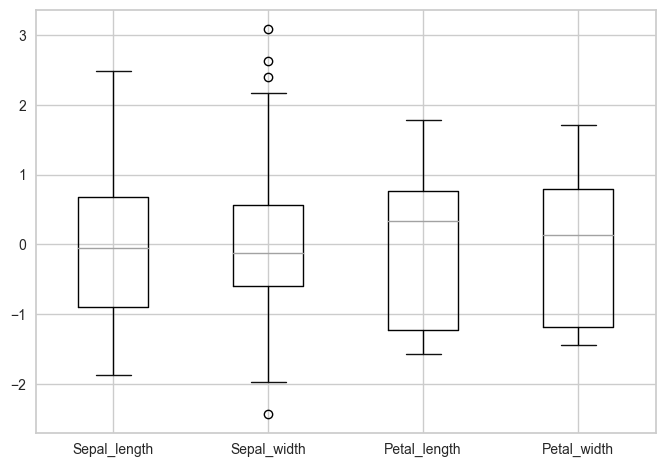

In [12]:
# Se recomienda escalar o estandarizar.
X2 = pd.DataFrame(scale(X))
X2.columns = ['Sepal_length', 'Sepal_width', 'Petal_length', 'Petal_width']

X2.boxplot()
round(X2.describe(),2)

In [13]:
## Aplicar Mezcla de Gaussianas

iris_GMM1 = GaussianMixture(n_components=3, random_state=0).fit(X)
iris_GMM2 = GaussianMixture(n_components=3, random_state=0, covariance_type='diag').fit(X2)
print(iris_GMM1.means_)
print(iris_GMM2.means_)

print(iris_GMM1.covariances_)
print(iris_GMM2.covariances_)

y_gmm1=iris_GMM1.predict(X)
y_gmm2=iris_GMM2.predict(X2)

pd.crosstab(y_gmm1, y_gmm2)


[[5.9170732  2.77804839 4.20540364 1.29848217]
 [5.006      3.428      1.462      0.246     ]
 [6.54639415 2.94946365 5.48364578 1.98726565]]
[[ 0.0735018  -0.73559739  0.33205695  0.22541722]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.05406288 -0.03719101  1.05639233  1.13419014]]
[[[0.2755171  0.09662295 0.18547072 0.05478901]
  [0.09662295 0.09255152 0.09103431 0.04299899]
  [0.18547072 0.09103431 0.20235849 0.06171383]
  [0.05478901 0.04299899 0.06171383 0.03233775]]

 [[0.121765   0.097232   0.016028   0.010124  ]
  [0.097232   0.140817   0.011464   0.009112  ]
  [0.016028   0.011464   0.029557   0.005948  ]
  [0.010124   0.009112   0.005948   0.010885  ]]

 [[0.38744093 0.09223276 0.30244302 0.06087397]
  [0.09223276 0.11040914 0.08385112 0.05574334]
  [0.30244302 0.08385112 0.32589574 0.07276776]
  [0.06087397 0.05574334 0.07276776 0.08484505]]]
[[0.34593335 0.47455386 0.08477801 0.09623694]
 [0.17877068 0.74619275 0.00954905 0.01885974]
 [0.47132437 0.44287239 0.09

col_0,0,1,2
row_0,,,
0,45,0,0
1,0,50,0
2,11,0,44


In [14]:
## Comparar con la verdadera etiqueta
print(pd.crosstab(y, y_gmm1))
print(pd.crosstab(y, y_gmm2))

col_0   0   1   2
row_0            
0       0  50   0
1      45   0   5
2       0   0  50
col_0   0   1   2
row_0            
0       0  50   0
1      49   0   1
2       7   0  43


In [15]:
#####################################################
## Visualización a través de componentes principales

# Componentes principales de Iris

pca_pipe1 = make_pipeline(StandardScaler(), PCA()) # con StandardScaler() escala interamente 
pca_pipe1.fit(X)  # sin escalar

# Se extrae el modelo entrenado del pipeline
modelo_pca1 = pca_pipe1.named_steps['pca']
print(modelo_pca1.explained_variance_ratio_*100)
print(modelo_pca1.explained_variance_ratio_.cumsum()*100)


# Se combierte el array a dataframe para añadir nombres a los ejes (vectores propios).
print(
pd.DataFrame(
    data    = modelo_pca1.components_,
    columns = X.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4']
))

[72.96244541 22.85076179  3.66892189  0.51787091]
[ 72.96244541  95.8132072   99.48212909 100.        ]
     Sepal_length  Sepal_width  Petal_length  Petal_width
PC1      0.521066    -0.269347      0.580413     0.564857
PC2      0.377418     0.923296      0.024492     0.066942
PC3      0.719566    -0.244382     -0.142126    -0.634273
PC4     -0.261286     0.123510      0.801449    -0.523597


In [16]:
# Proyección de las observaciones de entrenamiento
# ==============================================================================
proyecciones1 = pca_pipe1.transform(X=X)
proyecciones1 = pd.DataFrame(
    proyecciones1,
    columns = ['PC1', 'PC2', 'PC3', 'PC4'],
    index   = X.index
)

print(proyecciones1.head(10))

        PC1       PC2       PC3       PC4
0 -2.264703  0.480027  0.127706 -0.024168
1 -2.080961 -0.674134  0.234609 -0.103007
2 -2.364229 -0.341908 -0.044201 -0.028377
3 -2.299384 -0.597395 -0.091290  0.065956
4 -2.389842  0.646835 -0.015738  0.035923
5 -2.075631  1.489178 -0.026968 -0.006608
6 -2.444029  0.047644 -0.335470  0.036776
7 -2.232847  0.223148  0.088695  0.024612
8 -2.334640 -1.115328 -0.145077  0.026859
9 -2.184328 -0.469014  0.253766  0.039899


In [17]:
# Se crea un Dataframe con resultados
df_iris = pd.DataFrame() 
df_iris['Especie'] = y 

# guardan los resultados de los modelos
df_iris['GMM1'] = y_gmm1
df_iris['GMM2'] = y_gmm2

# se imprime las primeras 5 filas
df_iris.head(5) 

,Especie,GMM1,GMM2
0,0,1,1
1,0,1,1
2,0,1,1
3,0,1,1
4,0,1,1


In [18]:
# colores para Grupos
colors = {-1: "gray", 0: "red", 1: "blue", 2: "green", 3: "yellow", 4: "violet"}

color_esp = df_iris.Especie.map(colors)
color_gmm1 = df_iris.GMM1.map(colors)
color_gmm2 = df_iris.GMM2.map(colors)

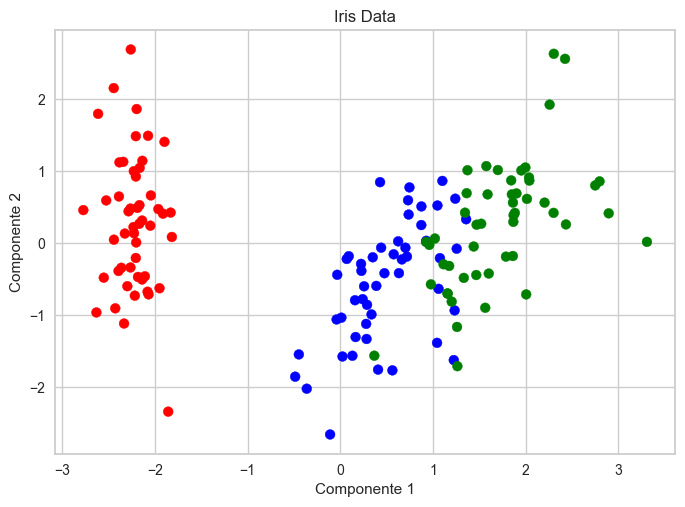

In [19]:
# Visualizacion con las primeras 2 componentes principales 
# Especies originales

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_esp)
plt.title('Iris Data')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()


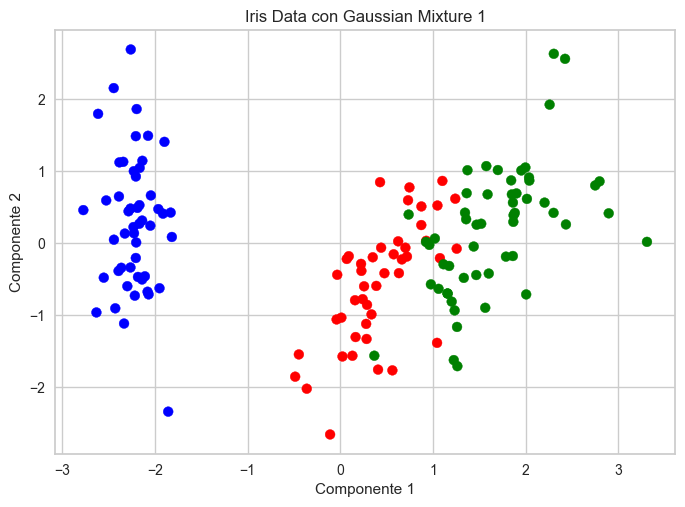

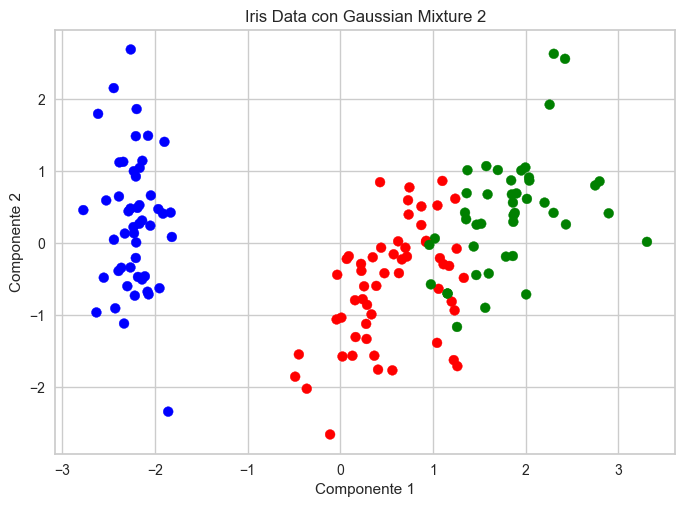

In [20]:
# Visualizacion con las primeras 2 componentes principales 
# Grupos formados con GaussianMixture

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_gmm1)
plt.title('Iris Data con Gaussian Mixture 1')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

plt.scatter(proyecciones1['PC1'], proyecciones1['PC2'], s = 50, c = color_gmm2)
plt.title('Iris Data con Gaussian Mixture 2')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

In [21]:
## Ejercicio1: Aplicar método silueta para evaluar los cluster construidos